<a href="https://colab.research.google.com/github/preethikamanokaran/Titanic-Data-Cleaning-Visualization/blob/main/Copy_of_Yet_another_copy_of_Titanic_Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
df = sns.load_dataset("titanic")

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
# Save the original dataset
df.to_csv("titanic_raw.csv", index=False)

print("Raw dataset saved successfully!")

Raw dataset saved successfully!


In [ ]:
print("Number of rows and columns:")
print(df.shape)

print("\nMissing values in each column:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

Number of rows and columns:
(891, 15)

Missing values in each column:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Number of duplicate rows:
107


In [ ]:
# Check missing values before cleaning
print("Missing values before cleaning:")
print(df.isnull().sum())

# Fill missing age values with the median age
df["age"] = df["age"].fillna(df["age"].median())

# Fill missing embarked values with the most common value
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

# Remove the deck column because it contains too many missing values
df = df.drop(columns=["deck"])

print("\nMissing values after cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Missing values after cleaning:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64


In [ ]:
# Check duplicates before removal
duplicates = df.duplicated().sum()
print("Duplicate rows found:", duplicates)

# Remove duplicate rows
df = df.drop_duplicates()

print("Duplicate rows after cleaning:", df.duplicated().sum())

Duplicate rows found: 116
Duplicate rows after cleaning: 0


In [ ]:
# Check for outliers in Fare using the IQR method

Q1 = df["fare"].quantile(0.25)
Q3 = df["fare"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

# Count outliers
outliers = df[(df["fare"] < lower_limit) | (df["fare"] > upper_limit)]

print("Number of fare outliers:", len(outliers))

Lower limit: -31.171850000000003
Upper limit: 73.41975000000001
Number of fare outliers: 102


In [ ]:
# Remove fare outliers
df = df[(df["fare"] >= lower_limit) & (df["fare"] <= upper_limit)]

print("Dataset shape after removing outliers:", df.shape)

Dataset shape after removing outliers: (673, 14)


In [ ]:
print("Remaining missing values:")
print(df.isnull().sum())

print("\nRemaining duplicate rows:")
print(df.duplicated().sum())

print("\nFinal dataset shape:")
print(df.shape)

Remaining missing values:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

Remaining duplicate rows:
0

Final dataset shape:
(673, 14)


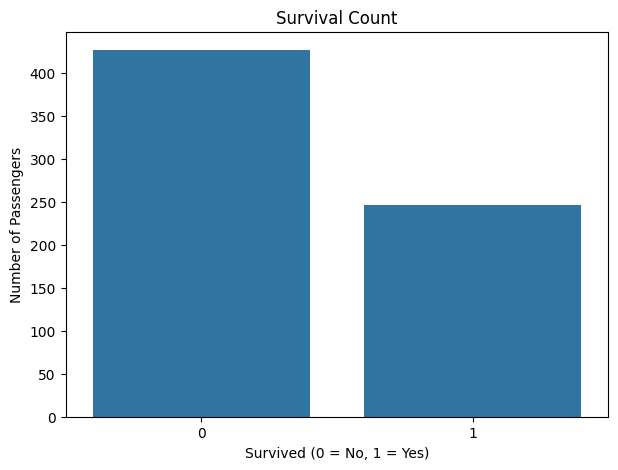

In [ ]:
# Visualization 1: Survival Count

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="survived")

plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()

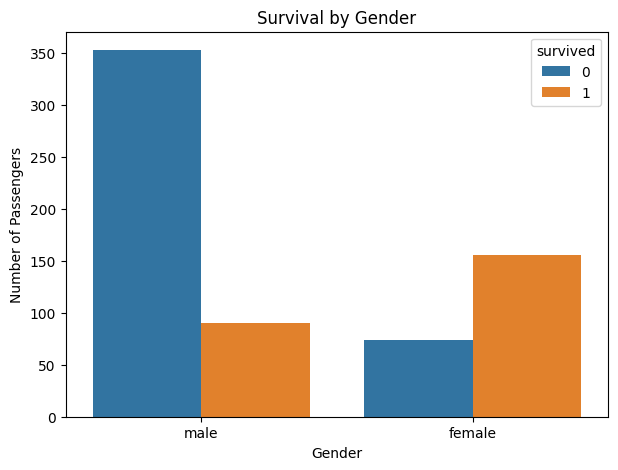

In [ ]:
# Visualization 2: Survival by Gender

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="sex", hue="survived")

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

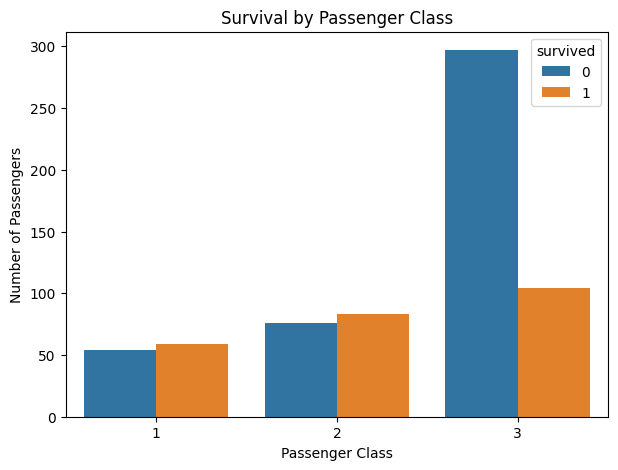

In [ ]:
# Visualization 3: Survival by Passenger Class

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="pclass", hue="survived")

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

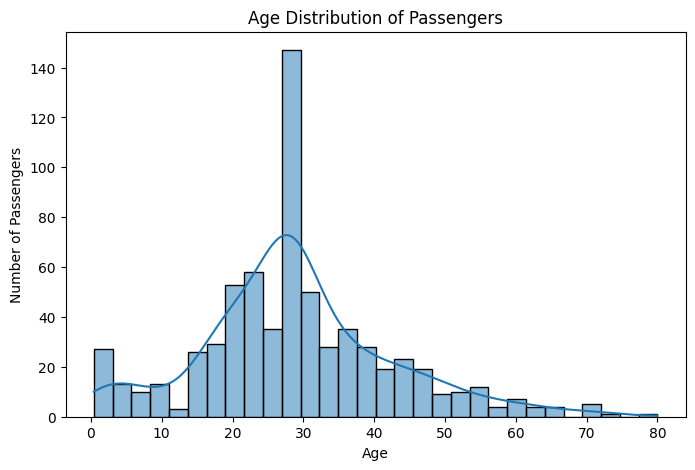

In [ ]:
# Visualization 4: Age Distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="age", bins=30, kde=True)

plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

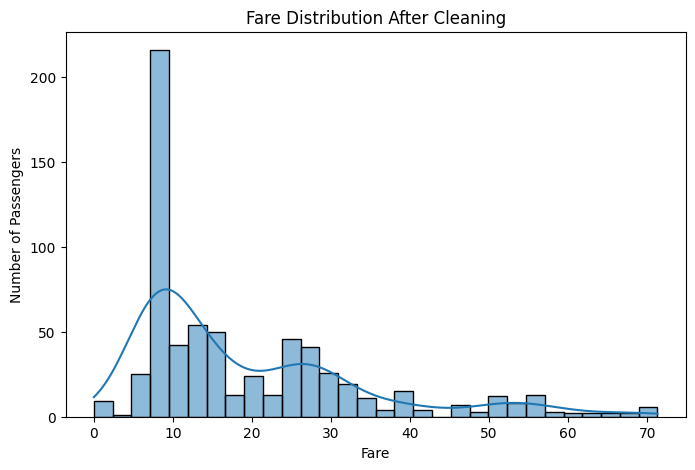

In [ ]:
# Visualization 5: Fare Distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="fare", bins=30, kde=True)

plt.title("Fare Distribution After Cleaning")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.show()

In [ ]:
# Key Insights

print("KEY INSIGHTS")
print("1. The dataset contains passengers who survived and passengers who did not survive.")
print("2. Survival rates differ between male and female passengers.")
print("3. Passenger class shows a noticeable relationship with survival.")
print("4. Most passengers belong to a particular age range.")
print("5. Missing values, duplicate records, and fare outliers were handled during data cleaning.")

KEY INSIGHTS
1. The dataset contains passengers who survived and passengers who did not survive.
2. Survival rates differ between male and female passengers.
3. Passenger class shows a noticeable relationship with survival.
4. Most passengers belong to a particular age range.
5. Missing values, duplicate records, and fare outliers were handled during data cleaning.


In [ ]:
# Save the cleaned dataset

df.to_csv("titanic_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [ ]:
# Conclusion

print("""
CONCLUSION

The Titanic dataset was successfully cleaned and analyzed.
Missing values were handled, duplicate records were removed,
and fare outliers were identified and removed.

Several visualizations were created to understand survival
patterns based on gender, passenger class, age, and fare.
The cleaned dataset was saved for further analysis.
""")


CONCLUSION

The Titanic dataset was successfully cleaned and analyzed.
Missing values were handled, duplicate records were removed,
and fare outliers were identified and removed.

Several visualizations were created to understand survival
patterns based on gender, passenger class, age, and fare.
The cleaned dataset was saved for further analysis.



In [ ]:
from google.colab import files
files.download("titanic_raw.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download("titanic_raw.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>